# Torondel et al. (2016) — Pit Latrine Bacterial Ecology, Reproduced with pyloseq

**Reference:** Torondel B, Ensink JHJ, Gundogdu O, Ijaz UZ, Parkhill J, Abdelahi F, Nguyen V-A, Sudgen S, Gibson W, Walker AW, Quince C (2016). *Assessment of the influence of intrinsic environmental and geographical factors on the bacterial ecology of pit latrines.* **Microbial Biotechnology** 9(2): 209–223. DOI: [10.1111/1751-7915.12334](https://doi.org/10.1111/1751-7915.12334).

Bacterial communities from 30 pit latrines in Tanzania and Vietnam were profiled by 16S rRNA pyrosequencing and related to environmental variables (pH, temperature, organic-matter content/composition) and geography. The dataset is the basis of Umer Ijaz's widely-used phyloseq tutorial ([userweb.eng.gla.ac.uk/umer.ijaz/bioinformatics/ecological.html](http://userweb.eng.gla.ac.uk/umer.ijaz/bioinformatics/ecological.html)) and of the **microbiomeSeq** package.

This notebook reproduces the `phyloseq.R` workflow from that tutorial using the Python `pyloseq` package, following the same structure as our [McMurdie & Holmes (2013)](06_mcmurdie_holmes_2013.ipynb) reproduction. Each code cell shows the original R call it mirrors. Where pyloseq diverges from R phyloseq, the difference is called out inline and summarized at the end.

---
### Setup

In [1]:
import warnings

import pandas as pd
from skbio.stats.distance import permanova

from pyloseq import (
    OtuTable,
    Phyloseq,
    PhyTree,
    SampleData,
    TaxTable,
    distance,
    estimate_richness,
    make_network,
    ordinate,
    plot_bar,
    plot_heatmap,
    plot_network,
    plot_ordination,
    plot_richness,
    plot_tree,
    prune_taxa,
    subset_samples,
    subset_taxa,
)

warnings.filterwarnings("ignore")

DATA = "data/torondel"

---
### 1. Load and Build the Phyloseq Object

Four files from the tutorial:

| File | Contents |
|------|----------|
| `All_Good_P2_C03.csv` | OTU abundance table (OTUs × samples) |
| `ENV_pitlatrine.csv` | Environmental / sample metadata |
| `All_Good_P2_C03_Taxonomy.csv` | RDP taxonomy per OTU (Domain → Genus) |
| `All_Good_P2_C03.tre` | FastTree phylogeny (Newick) |

The sample names encode three grouping factors — e.g. `T_2_1` is **Country** `T` (Tanzania; `V` = Vietnam), **Latrine** `2`, **Depth** `1`. We split these out into metadata columns exactly as the R code does with `strsplit(..., "_")`.

In [2]:
# R: abund_table <- read.csv("All_Good_P2_C03.csv", row.names=1, check.names=FALSE)
abund_table = pd.read_csv(f"{DATA}/All_Good_P2_C03.csv", index_col=0)  # OTUs x samples

# R: meta_table <- read.csv("ENV_pitlatrine.csv", row.names=1, check.names=FALSE)
meta_table = pd.read_csv(f"{DATA}/ENV_pitlatrine.csv", index_col=0)

# R: grouping_info <- ... strsplit(rownames(meta_table), "_") ; colnames <- Country/Latrine/Depth
grouping = meta_table.index.to_series().str.split("_", expand=True)
meta_table["Country"] = grouping[0]
meta_table["Latrine"] = grouping[1]
meta_table["Depth"] = grouping[2]

# R: abund_table <- abund_table[rownames(abund_table) %in% rownames(meta_table), ]
#    (R transposes first so samples are rows; here samples are columns, so we filter columns)
common = [s for s in abund_table.columns if s in meta_table.index]
abund_table = abund_table[common]
meta_table = meta_table.loc[common]

# R: OTU_taxonomy <- read.csv("All_Good_P2_C03_Taxonomy.csv", row.names=1, check.names=FALSE)
otu_taxonomy = pd.read_csv(f"{DATA}/All_Good_P2_C03_Taxonomy.csv", index_col=0).reindex(abund_table.index)

print(f"OTU table: {abund_table.shape[0]} OTUs x {abund_table.shape[1]} samples")
print(f"Metadata:  {meta_table.shape[1]} variables -> {list(meta_table.columns)}")
meta_table.head()

OTU table: 12715 OTUs x 81 samples
Metadata:  14 variables -> ['pH', 'Temp', 'TS', 'VS', 'VFA', 'CODt', 'CODs', 'perCODsbyt', 'NH4', 'Prot', 'Carbo', 'Country', 'Latrine', 'Depth']


,pH,Temp,TS,VS,VFA,CODt,CODs,perCODsbyt,NH4,Prot,Carbo,Country,Latrine,Depth
Samples,,,,,,,,,,,,,,
T_2_1,7.82,25.1,14.53,71.33,71.0,874,311,36,3.3,35.4,22.0,T,2,1
T_2_2,6.49,29.6,13.91,64.93,3.7,389,180,46,6.2,29.3,25.0,T,2,2
T_2_3,6.46,27.9,29.45,26.85,27.5,161,35,22,2.4,19.4,31.0,T,2,3
T_2_6,7.69,28.7,65.52,7.03,1.5,57,3,6,0.8,0.0,14.0,T,2,6
T_2_7,7.48,29.8,36.03,34.11,1.1,107,9,8,0.7,14.1,28.0,T,2,7


#### Rooting the tree

The FastTree output is **unrooted**. R phyloseq silently roots an unrooted tree on the fly (picking a random tip) inside `ordinate(..., "unifrac")`; **pyloseq requires an explicitly rooted tree** and raises `ValueError: The tree must be rooted` otherwise. The tutorial itself recommends principled **midpoint rooting** (via `phangorn::midpoint` for the GUniFrac section), so we root once up front and use it everywhere. This is the first behavioral difference vs. R phyloseq (see the closing notes).

In [3]:
# R (GUniFrac section): midpoint(phy_tree(physeq_subset))  -- phangorn midpoint rooting
unrooted = PhyTree.from_newick(open(f"{DATA}/All_Good_P2_C03.tre").read())
phy_tree = PhyTree.from_newick(str(unrooted._tree.root_at_midpoint()))
print(f"Unrooted tips: {unrooted.n_tips} | rooted: {phy_tree.is_rooted}")

Unrooted tips: 11853 | rooted: True


In [4]:
# R: OTU = otu_table(as.matrix(abund_table), taxa_are_rows=FALSE)
#    TAX = tax_table(as.matrix(OTU_taxonomy))
#    SAM = sample_data(meta_table)
#    physeq <- merge_phyloseq(phyloseq(OTU, TAX), SAM, OTU_tree)
physeq = Phyloseq(
    otu=OtuTable(abund_table, taxa_are_rows=True),
    sam=SampleData(meta_table),
    tax=TaxTable(otu_taxonomy),
    tree=phy_tree,
)

print(f"Taxa:    {physeq.ntaxa}")
print(f"Samples: {physeq.nsamples}")
print(f"Ranks:   {physeq.rank_names}")
print(f"Countries: {sorted(meta_table['Country'].unique())}  (T=Tanzania, V=Vietnam)")

Taxa:    12715
Samples: 81
Ranks:   ['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus']
Countries: ['T', 'V']  (T=Tanzania, V=Vietnam)


---
### 2. Alpha Diversity — `plot_richness`

Per-sample richness estimators, samples grouped by **Country** on the x-axis and colored by **Depth**.

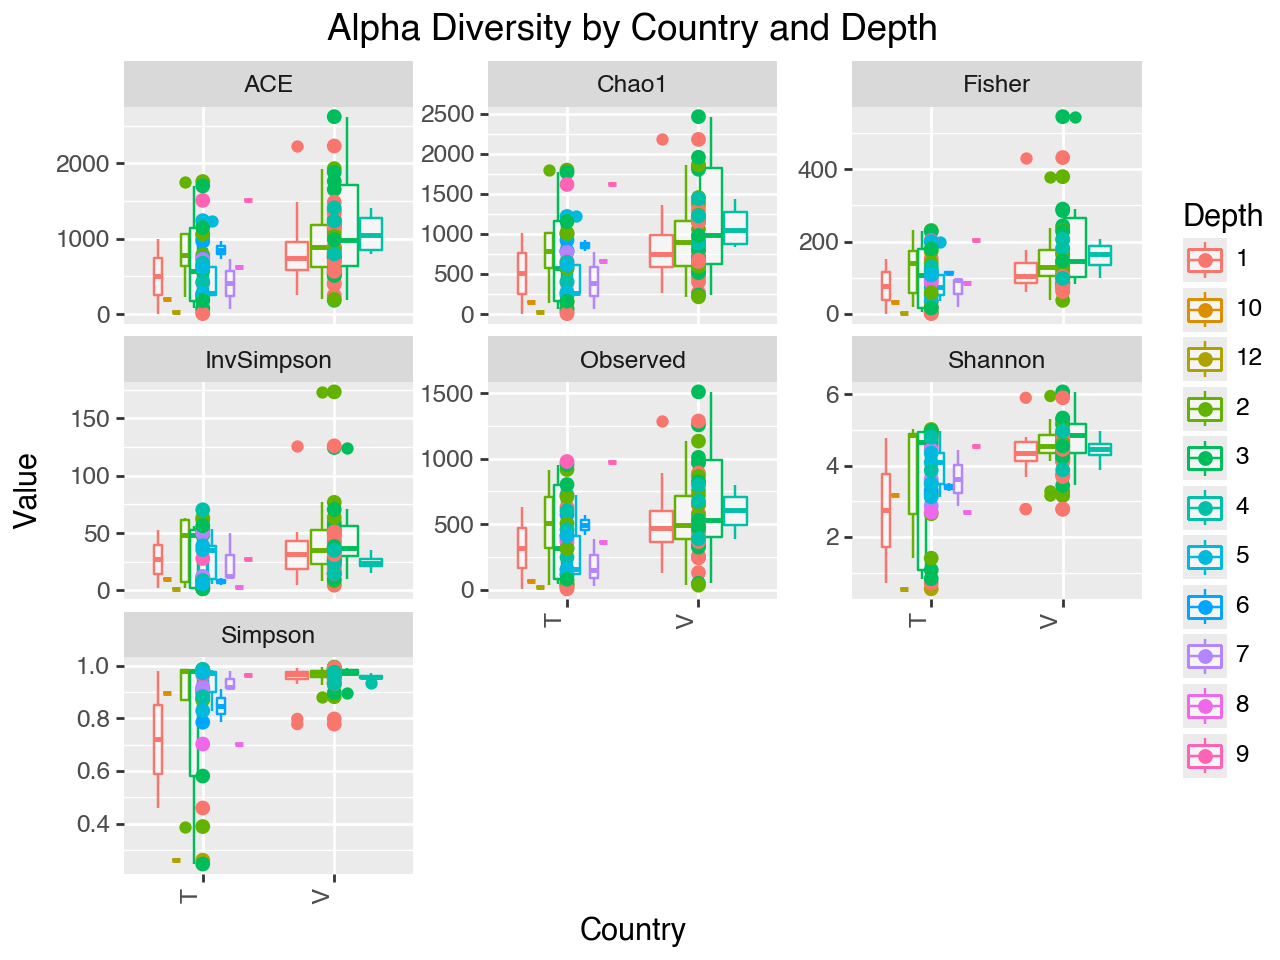

In [5]:
# R: p <- plot_richness(physeq, x="Country", color="Depth") + theme_bw()
p = plot_richness(
    physeq,
    x="Country",
    color="Depth",
    title="Alpha Diversity by Country and Depth",
)
p

---
### 3. Phylogenetic Tree of Prevotellaceae at Depth 1 — `plot_tree`

Subset to the shallowest latrine layer (`Depth == "1"`) and to the family *Prevotellaceae*, then draw the tree with tips colored by country, labelled by genus, and sized by abundance.

Prevotellaceae @ Depth 1: 105 OTUs x 22 samples


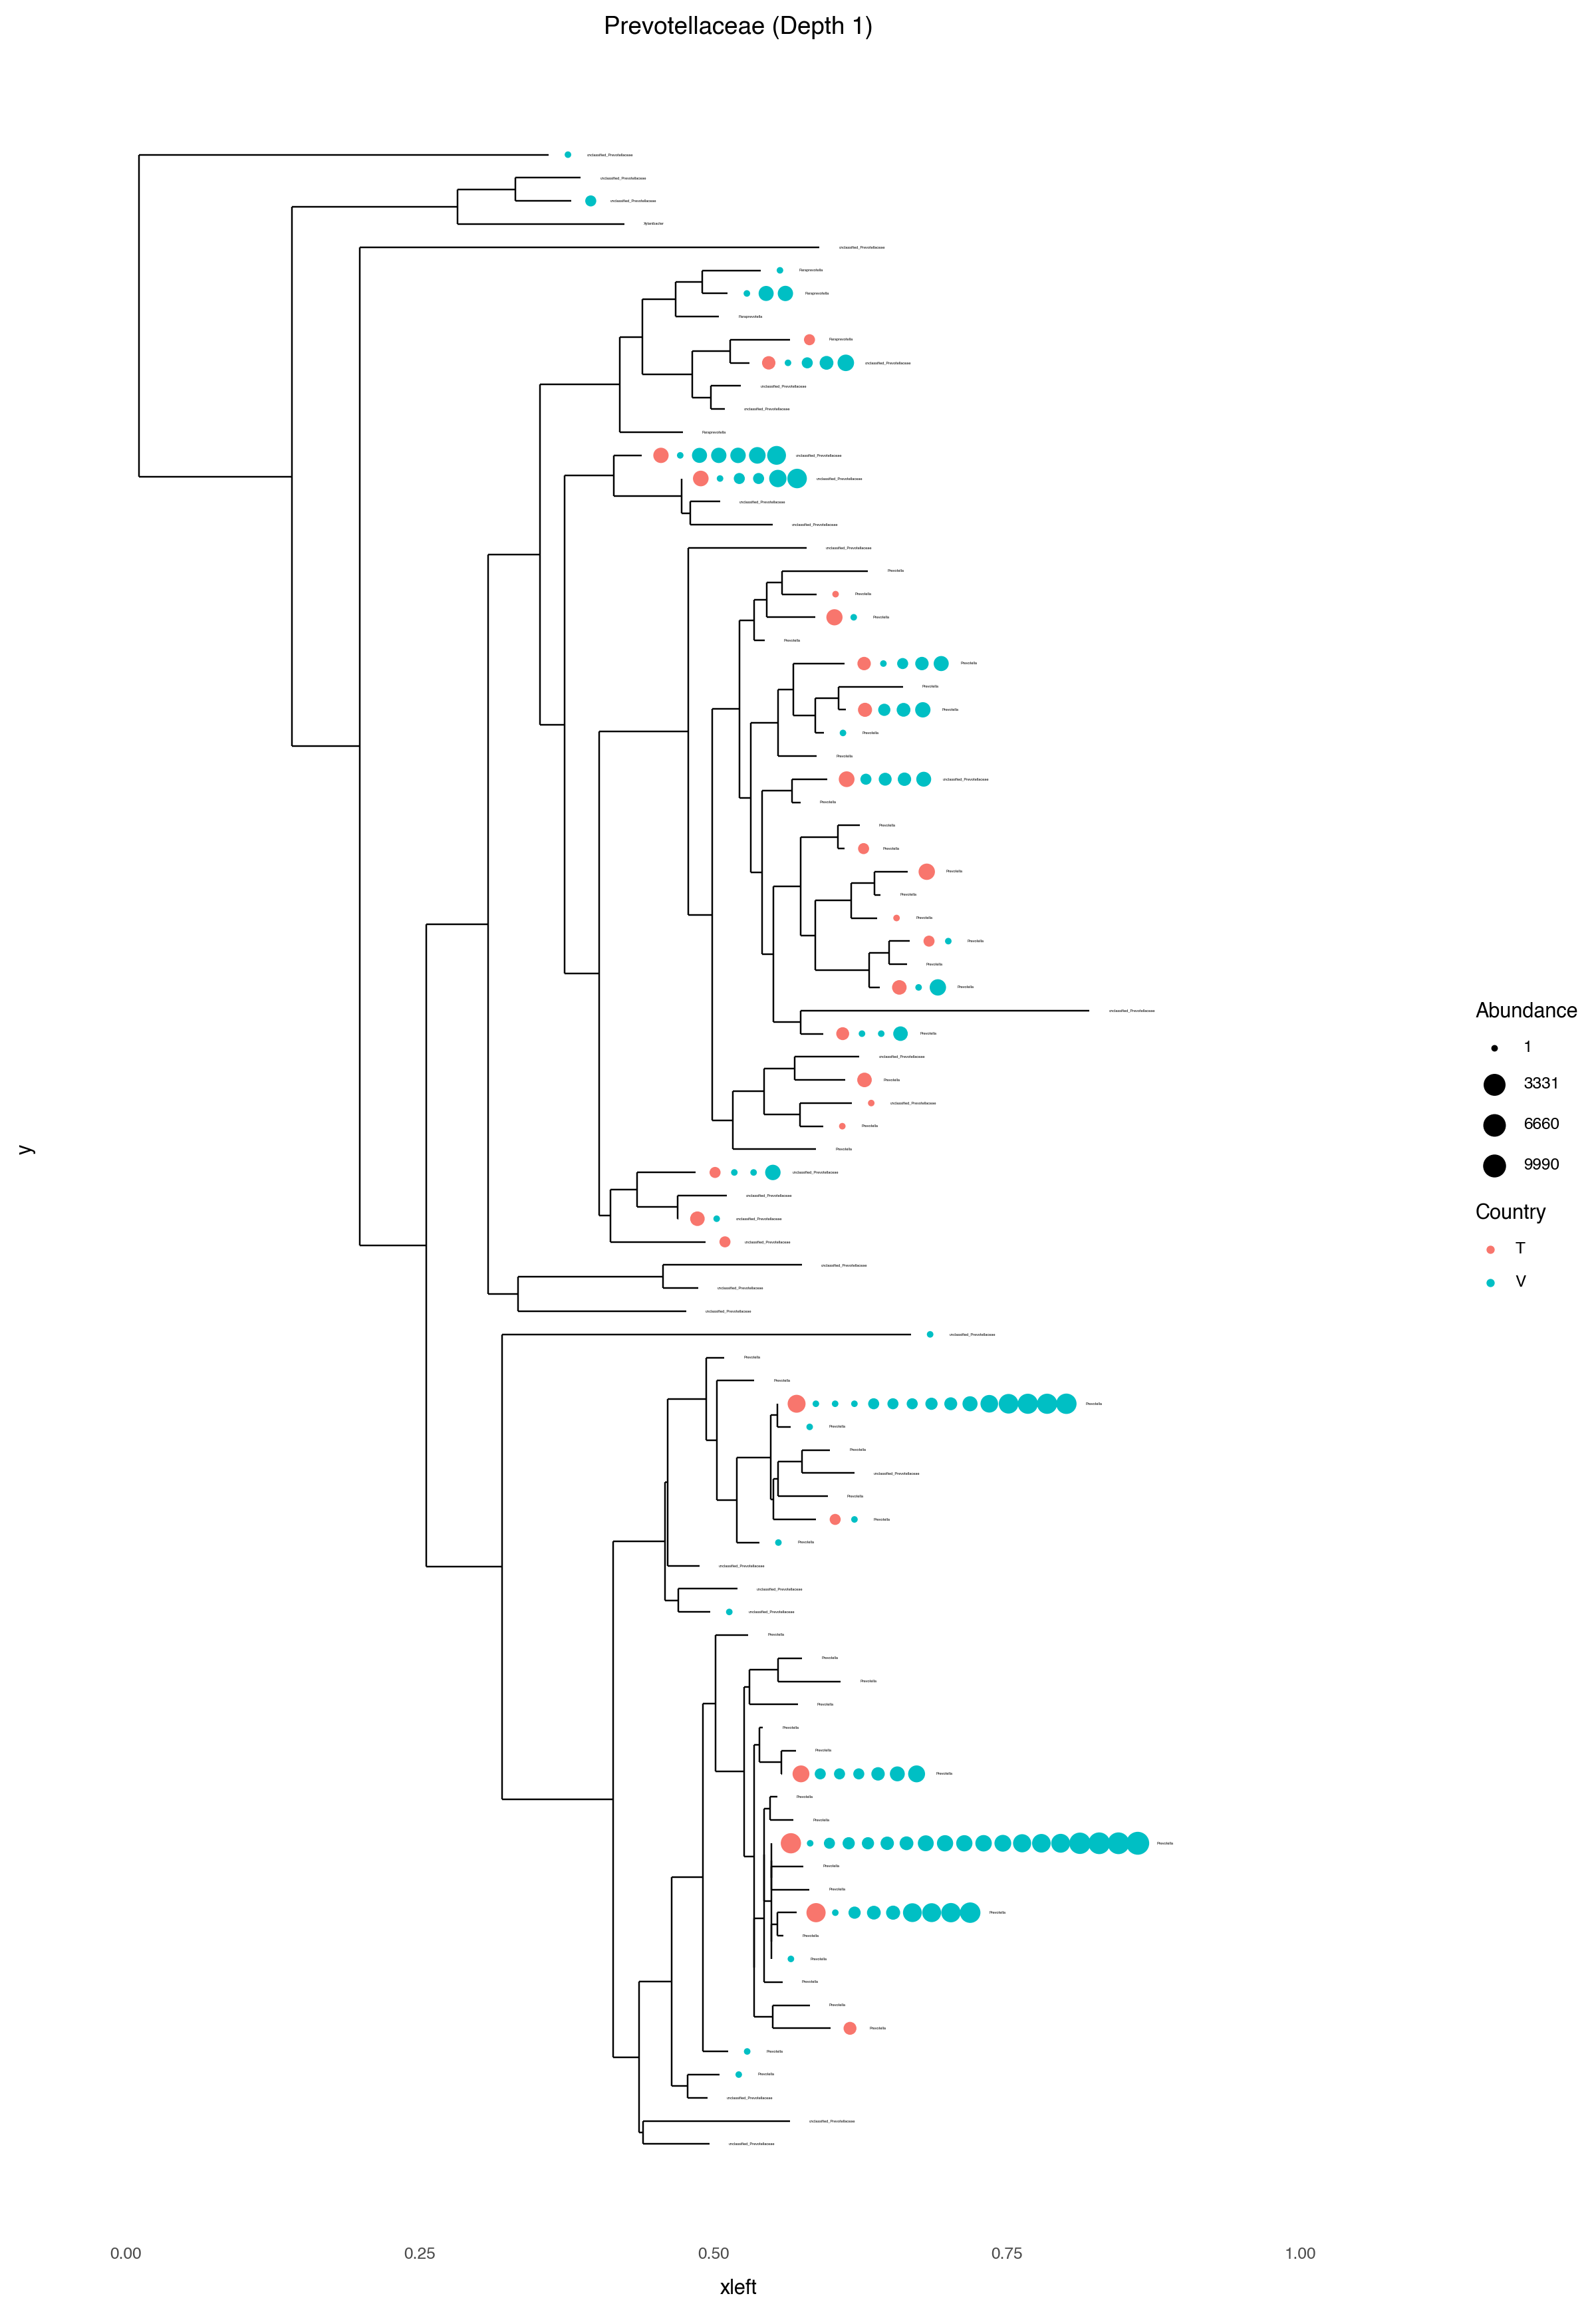

In [6]:
# R: physeq_subset <- subset_taxa(subset_samples(physeq, Depth=="1"), Family=="Prevotellaceae")
prevotella = subset_taxa(
    subset_samples(physeq, 'Depth == "1"'),
    'Family == "Prevotellaceae"',
)
print(f"Prevotellaceae @ Depth 1: {prevotella.ntaxa} OTUs x {prevotella.nsamples} samples")

# R: plot_tree(physeq_subset, color="Country", label.tips="Genus", size="abundance", text.size=2)
p = plot_tree(
    prevotella,
    color="Country",
    label_tips="Genus",
    size="Abundance",
    text_size=2,
    title="Prevotellaceae (Depth 1)",
)
p

---
### 4. Restrict to the 500 Most Abundant OTUs

The composition, heatmap, ordination and network plots all operate on the 500 highest-abundance OTUs, as in the tutorial.

In [7]:
# R: physeq_subset <- prune_taxa(names(sort(taxa_sums(physeq), TRUE)[1:500]), physeq)
top500 = physeq.taxa_sums().sort_values(ascending=False).index[:500]
physeq_subset = prune_taxa(list(top500), physeq)
print(f"Subset: {physeq_subset.ntaxa} taxa x {physeq_subset.nsamples} samples")

Subset: 500 taxa x 81 samples


---
### 5. Abundance Heatmap — `plot_heatmap`

The R call uses `method=NULL` (no ordination reordering) with `sample.label="Country"` and `taxa.label="Class"`. pyloseq's `plot_heatmap` **does not accept `method=None` nor `sample.label`/`taxa.label` arguments** — it always reorders rows/columns by an ordination. We therefore use the default NMDS/Bray-Curtis ordering. This is a behavioral gap (see closing notes).

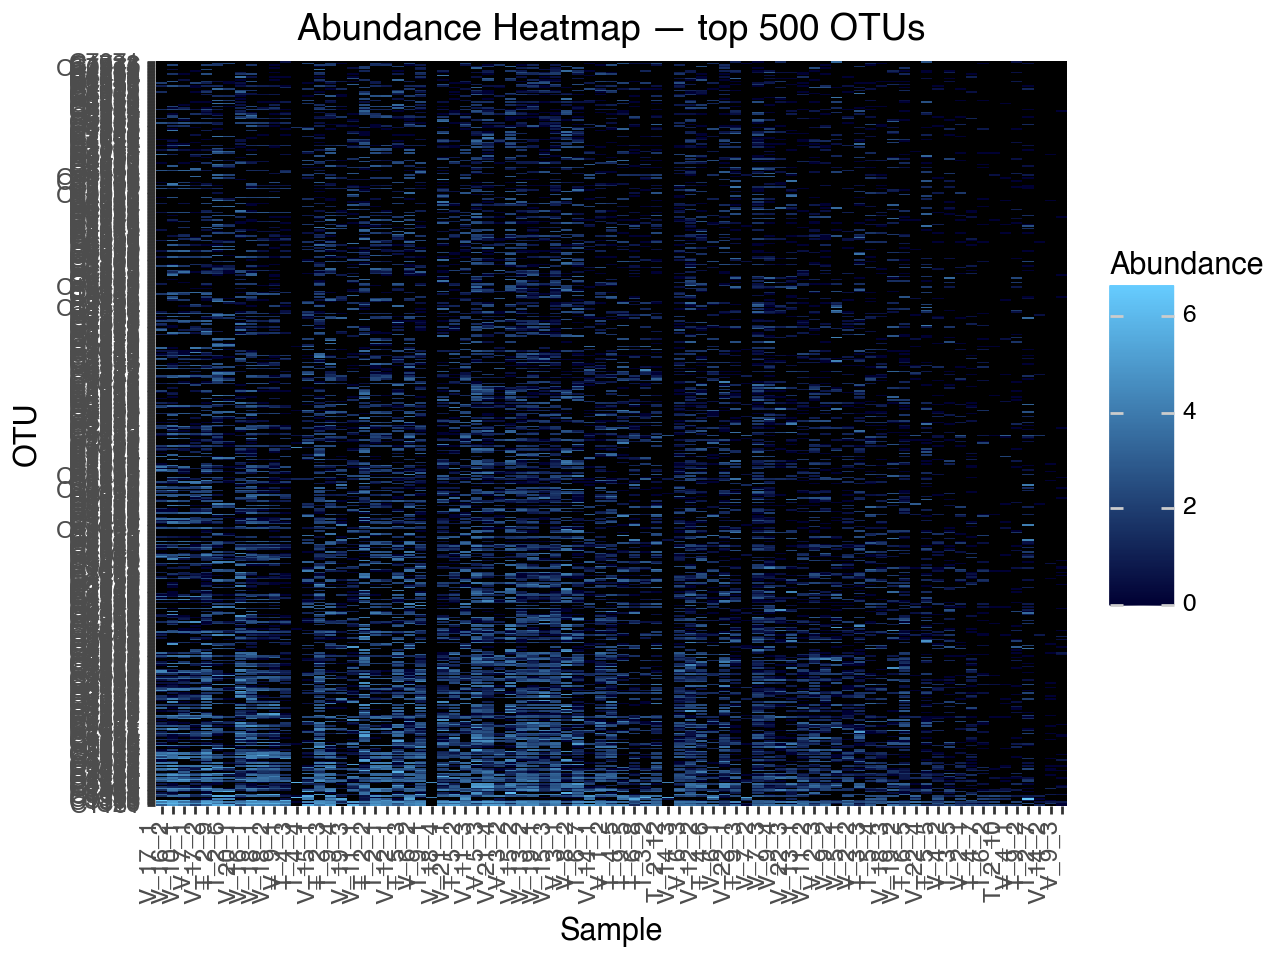

In [8]:
# R: plot_heatmap(physeq_subset, method=NULL, sample.label="Country", taxa.label="Class")
#    pyloseq has no method=NULL / label options; default NMDS+Bray ordering used instead.
p = plot_heatmap(
    physeq_subset,
    title="Abundance Heatmap — top 500 OTUs",
)
p

---
### 6. Taxonomic Composition — `plot_bar`

Stacked phylum abundance per country, and a faceted version with one panel per country.

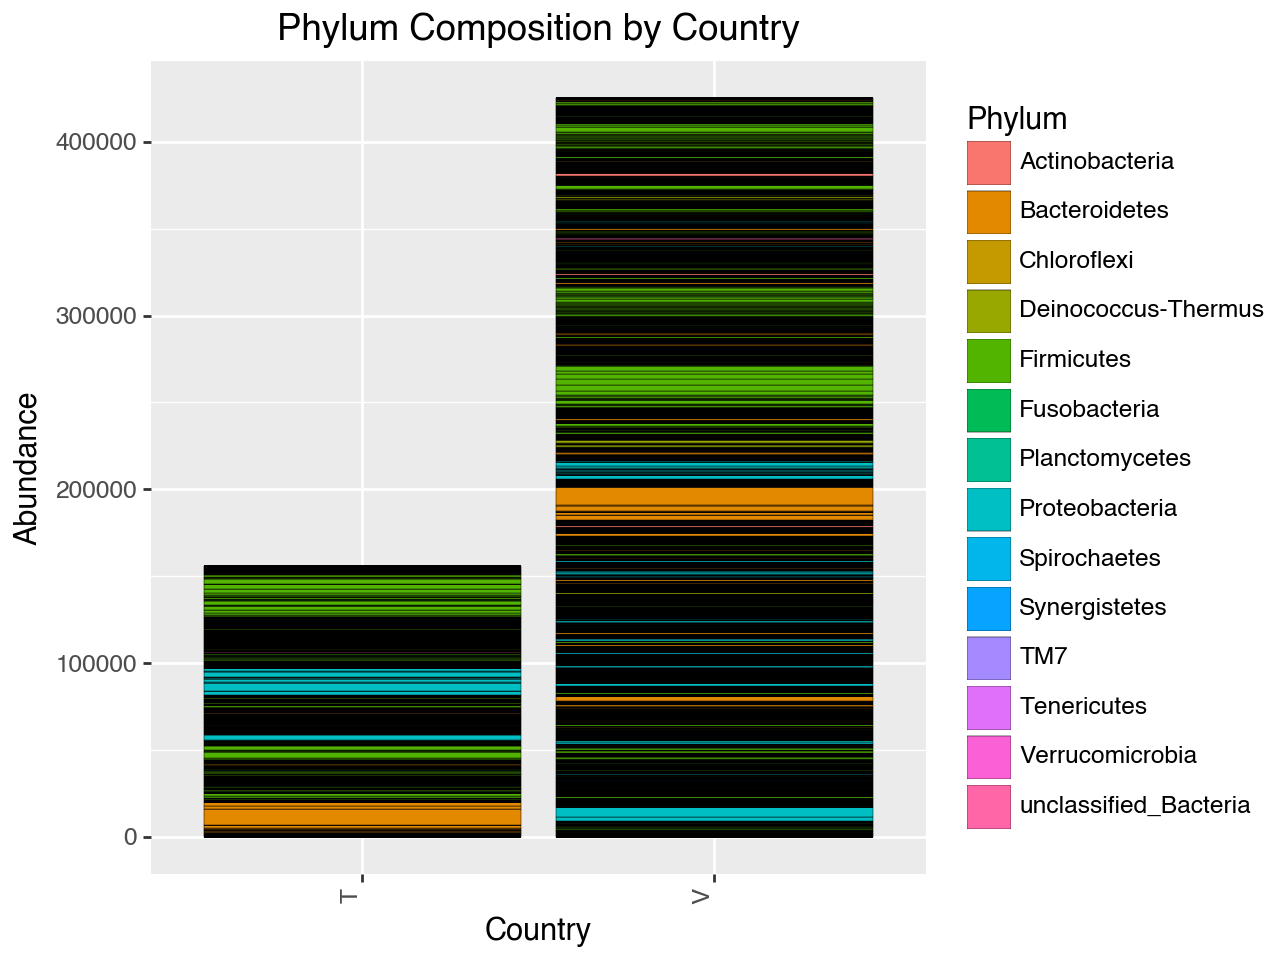

In [9]:
# R: plot_bar(physeq_subset, x="Country", fill="Phylum") + theme_bw()
p = plot_bar(
    physeq_subset,
    x="Country",
    fill="Phylum",
    title="Phylum Composition by Country",
)
p

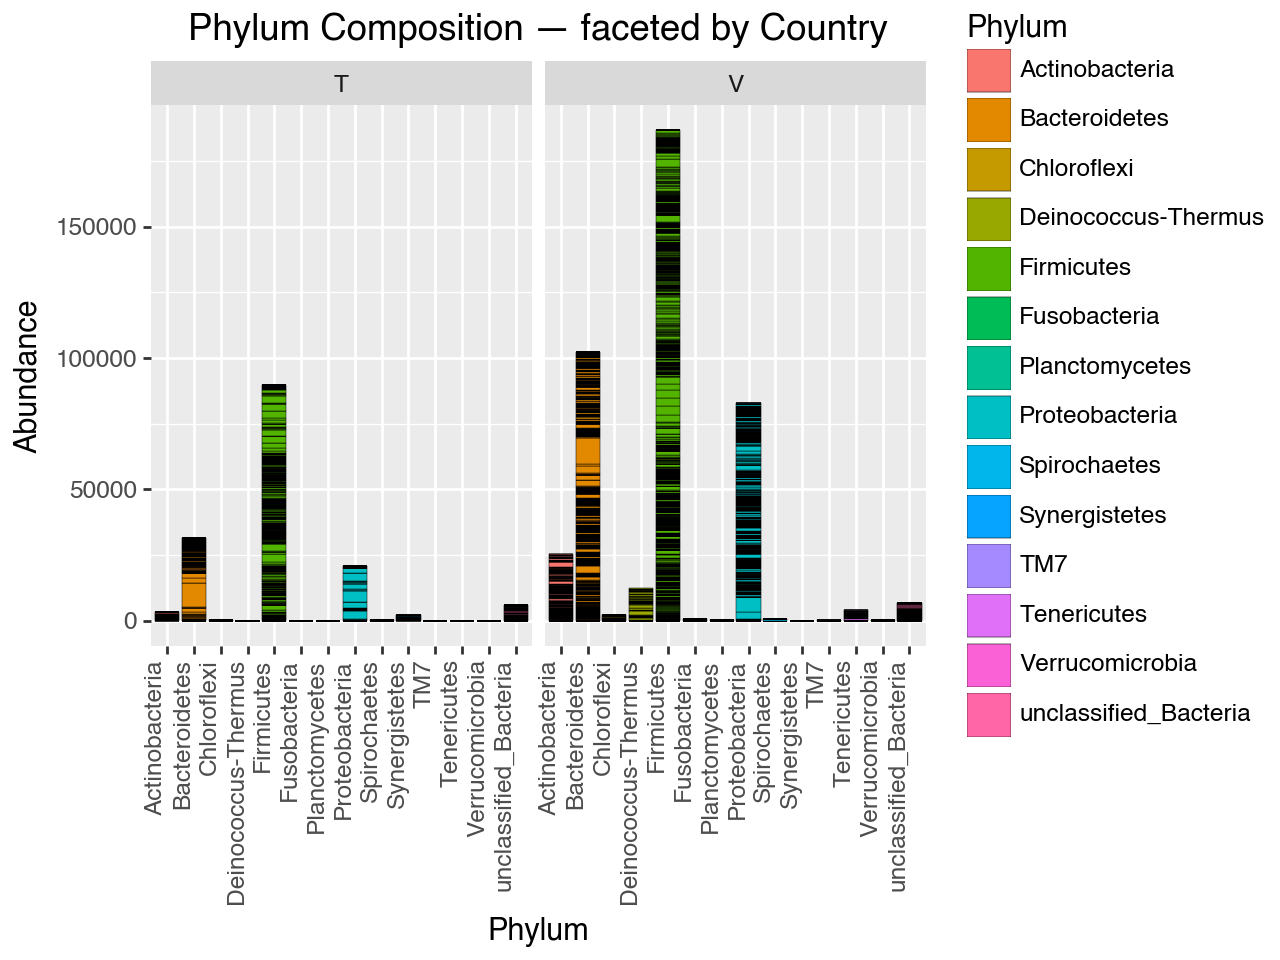

In [10]:
# R: plot_bar(physeq_subset, x="Phylum", fill="Phylum", facet_grid=~Country) + theme_bw()
p = plot_bar(
    physeq_subset,
    x="Phylum",
    fill="Phylum",
    facet_grid="~Country",
    title="Phylum Composition — faceted by Country",
)
p

---
### 7. Beta Diversity — Weighted & Unweighted UniFrac PCoA

The R code builds a PCoA on abundance-weighted UniFrac via `ordinate(physeq_subset, method="PCoA", distance="unifrac", weighted=TRUE)`, then explores GUniFrac's alpha-parameterized variants (`d_0`, `d_0.5`, `d_VAW`, ...). The GUniFrac alpha family lives in a **separate R package** (`GUniFrac`), not phyloseq, and is not part of pyloseq; we reproduce the two phyloseq-native endpoints — **weighted** and **unweighted** UniFrac.

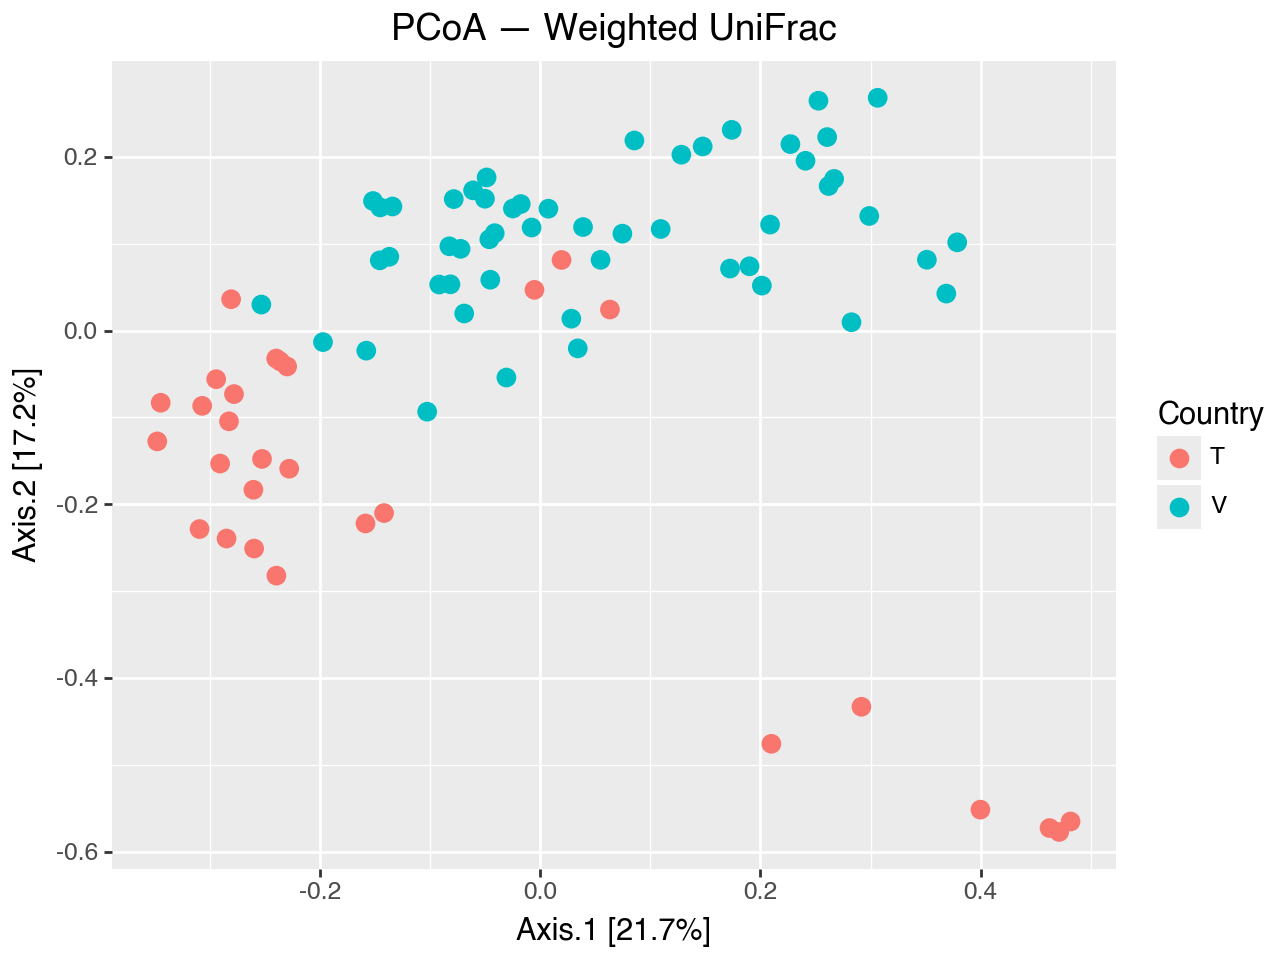

In [11]:
# R: ord <- ordinate(physeq_subset, method="PCoA", distance="unifrac", weighted=TRUE)
#    plot_ordination(physeq_subset, ord, color="Country", title="...Weighted Unifrac")
ord_w = ordinate(physeq_subset, method="PCoA", distance="wunifrac")
p = plot_ordination(
    physeq_subset,
    ord_w,
    color="Country",
    title="PCoA — Weighted UniFrac",
)
p

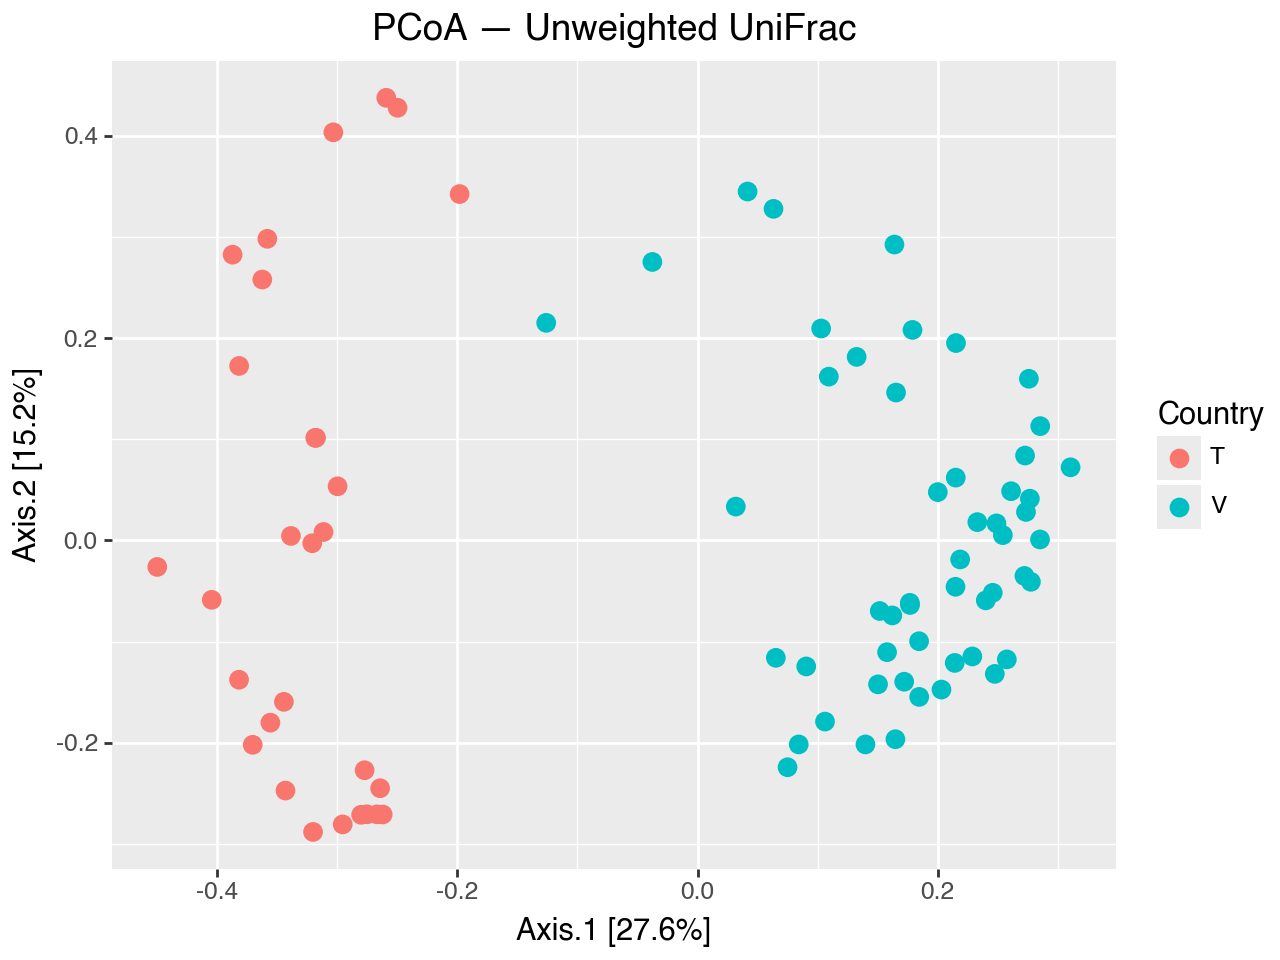

In [12]:
# Unweighted UniFrac (R GUniFrac d_UW analogue, phyloseq-native here)
ord_u = ordinate(physeq_subset, method="PCoA", distance="unifrac")
p = plot_ordination(
    physeq_subset,
    ord_u,
    color="Country",
    title="PCoA — Unweighted UniFrac",
)
p

---
### 8. PERMANOVA — does community structure differ by country?

The tutorial runs vegan's `adonis(as.dist(d5) ~ Country)` and reports F ≈ 14.56, R² ≈ 0.156, p = 0.001. pyloseq has **no `adonis` wrapper**, but a PERMANOVA on the same distance matrix is one call away via scikit-bio. We test on weighted UniFrac (closest phyloseq-native distance to the GUniFrac α=0.5 used in R), expecting a comparable, highly-significant country effect.

In [13]:
# R: adonis(as.dist(d5) ~ as.matrix(sample_data(physeq_subset)[,"Country"]))
dm = distance(physeq_subset, method="wunifrac")
groups = physeq_subset.sample_data.to_frame().loc[list(dm.ids), "Country"]
result = permanova(dm, groups)
print(result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      81
number of groups                  2
test statistic            13.603723
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


---
### 9. Co-occurrence Network — `make_network` / `plot_network`

The R code draws a sample network with `plot_net(physeq_subset, distance=as.dist(d5), maxdist=0.4, color="Country", shape="Latrine")`. Using a Bray-Curtis distance with the same `max_dist = 0.4` threshold, samples cluster strongly by country.

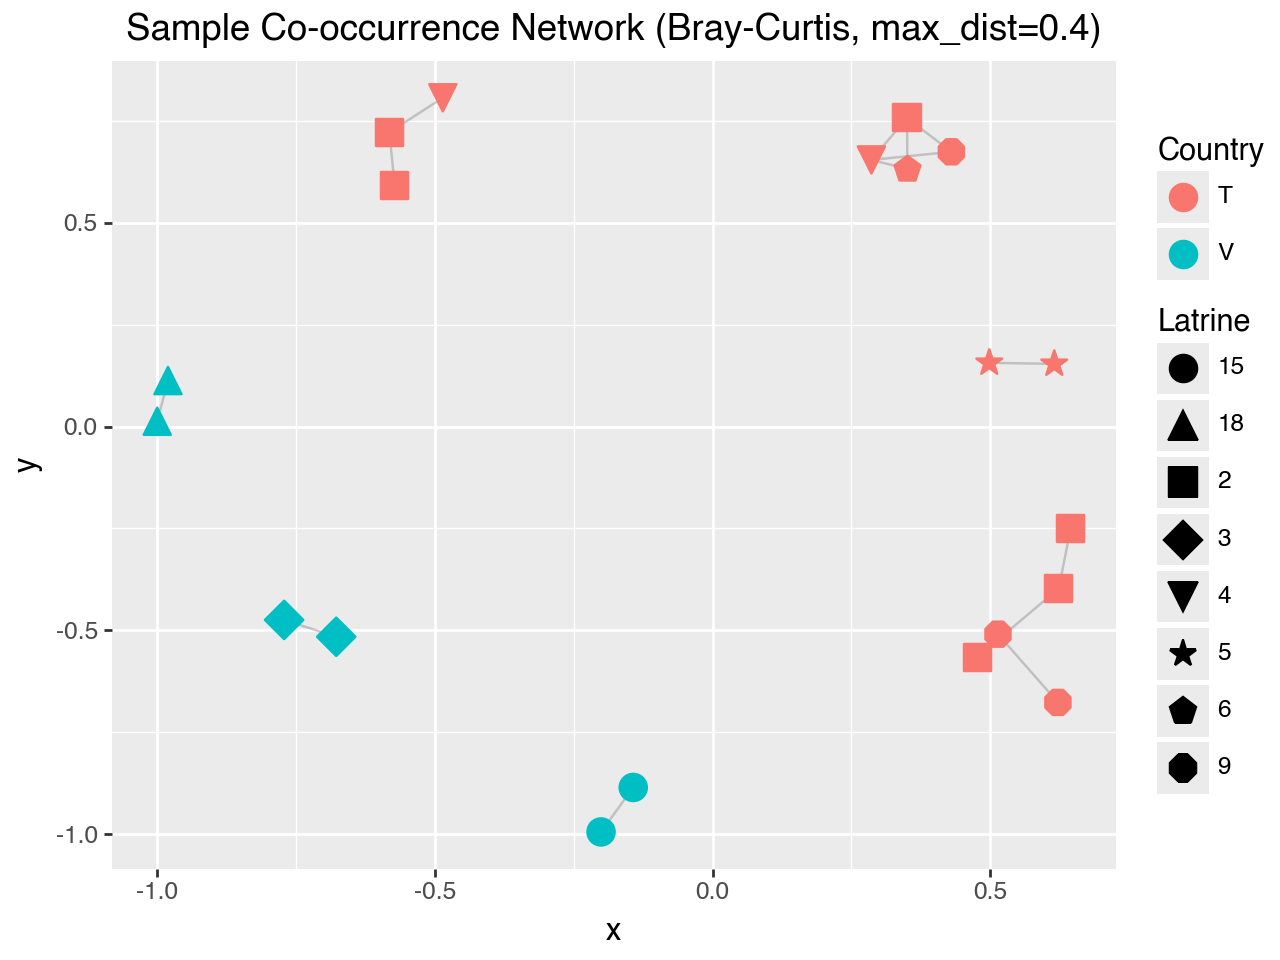

In [14]:
# R: plot_net(physeq_subset, distance=..., maxdist=0.4, color="Country", shape="Latrine")
g = make_network(physeq_subset, kind="samples", distance="bray", max_dist=0.4)
p = plot_network(
    g,
    physeq_subset,
    color="Country",
    shape="Latrine",
    title="Sample Co-occurrence Network (Bray-Curtis, max_dist=0.4)",
)
p

---
## Reproduction Notes & Behavioral Gaps

The phyloseq-native workflow reproduces cleanly. Differences from R phyloseq encountered along the way:

1. **Tree rooting is not automatic.** R phyloseq roots an unrooted tree on the fly inside `ordinate(..., "unifrac")` (by picking a random tip); pyloseq raises `ValueError: The tree must be rooted`. We midpoint-root explicitly up front — arguably the better behavior, but it is a divergence worth documenting. *Candidate enhancement: auto-root (with a warning) inside `unifrac`/`ordinate`.*

2. **`plot_heatmap` lacks `method=NULL` and `sample.label`/`taxa.label`.** pyloseq always reorders by an ordination and labels with raw IDs. The R tutorial uses `method=NULL` (preserve input order) and human-readable axis labels. *Candidate enhancement: support `method=None` and label-by-variable.*

3. **No DESeq2 integration.** The tutorial's mean–variance *dispersion* analysis (`deseq_var` + `plot_dispersion`, justifying the negative-binomial model for amplicon counts) depends on the R DESeq package; pyloseq exposes no `phyloseq_to_deseq2` equivalent. Not reproduced here. *This remains the largest outstanding integration gap (also noted for McMurdie & Holmes 2013).*

4. **GUniFrac alpha-family distances** (`d_0`, `d_0.5`, `d_VAW`) come from the standalone `GUniFrac` R package, not phyloseq, and have no pyloseq counterpart. We reproduced the phyloseq-native weighted/unweighted UniFrac endpoints instead.

5. **No `adonis` wrapper.** PERMANOVA is available via scikit-bio's `permanova` on a pyloseq distance matrix, but there is no phyloseq-style convenience wrapper. *Candidate enhancement: a thin `adonis`/`permanova` helper.*

Everything else — `subset_samples`/`subset_taxa`, `prune_taxa` + `taxa_sums`, `plot_richness`, `plot_tree`, `plot_bar` (incl. `facet_grid`), `ordinate`/`plot_ordination`, `make_network`/`plot_network` — matched the R API directly.